# Lecture 6 — External forcing and circadian entrainment


In [28]:
# Housekeeping code...
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Patch

if Path("../media").exists():
    MEDIA = Path("../media")
    DATA = Path("../data/circadian")
elif Path("media").exists():
    MEDIA = Path("media")
    DATA = Path("data/circadian")
else:
    raise FileNotFoundError("Run this notebook from the course repository.")

TAU = 2 * np.pi
BLUE = "#3B6FB6"
ORANGE = "#D97706"
GOLD = "#C9A227"
PINK = "#B64E77"
OLIVE = "#718355"
GREEN = "#3A8D5D"
RED = "#C74632"
INK = "#263238"
GREY = "#9AA0A6"
LIGHT = "#E7EAED"
DAY = "#F6D66B"
NIGHT = "#D8DCE8"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 12,
    "legend.fontsize": 11,
    "axes.labelsize": 12,
})


def wrap_phase(theta):
    return (np.asarray(theta) + np.pi) % TAU - np.pi


def simulate_relative_phase(detuning, forcing, phi0, *, t_end, dt=0.01):
    steps = int(np.ceil(t_end / dt))
    time = np.arange(steps + 1) * dt
    phi = np.empty(steps + 1)
    phi[0] = phi0
    for step in range(steps):
        slope = detuning - forcing * np.sin(phi[step])
        midpoint = phi[step] + 0.5 * dt * slope
        phi[step + 1] = phi[step] + dt * (
            detuning - forcing * np.sin(midpoint)
        )
    return time, phi


def arrow(ax, start, end, color=INK, width=2.2, mutation_scale=16, **kwargs):
    patch = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=mutation_scale,
        linewidth=width,
        color=color,
        shrinkA=4,
        shrinkB=4,
        **kwargs,
    )
    ax.add_patch(patch)
    return patch


def shade_nights(ax, day_length, cycles=3):
    for cycle in range(cycles):
        start = 24 * cycle + day_length
        ax.axvspan(start, 24 * (cycle + 1), color=NIGHT, alpha=0.75, lw=0)


<img src="../media/circadian-across-life.png" width="1050" style="display: block; margin: 0 auto;">


## Why have a circadian clock?

| Organism | Daily timing |
| --- | --- |
| Cyanobacterium | Store carbon in daylight; use it at night |
| Plant | Prepare photosynthesis and stomatal opening before dawn |
| Fruit fly | Time activity, feeding, mating, and emergence |
| Mouse | Coordinate nocturnal activity, feeding, and physiology |
| Human | Coordinate sleep, alertness, hormone secretion, and metabolism |

An internal clock lets an organism act *before* the environment changes.

On earth, the day is between **23 h 59 min 39 s** and **24 h 00 min 30 s** long, varying through the year.


## Human circadian rhythms

### Two months underground

In 1962, Michel Siffre spent about two months in a cave without sunlight, a watch, or a calendar.

- Slept and ate when he wanted; used an electric light
- Called the surface when he woke, ate, and went to bed
- The surface team recorded the times without telling him

Sleep–wake cycles continued, but lost their alignment with the 24-hour day.

On September 14, he thought it was August 20!


<img src="../media/human-siffre-midnight-cave-1972.jpg" alt="Siffre’s illuminated camp inside Midnight Cave during his 1972 isolation experiment" width="850">


### Mars500: 520 days in isolation

Six men lived in a simulated spacecraft in Moscow during 2010–2011.

- No sunlight; crew-controlled artificial lighting at will
- Shared work, meals, and a nominal 24-hour schedule
- Wrist activity monitors used to estimate when each person slept

Two different crew members: Black intervals show sleep from wrist monitors 

<img src="../media/human-mars500-actograms-basner-2013.png" alt="Mars500 actograms: diagonal sleep bands in participant B and nearly vertical bands in C" width="950">

- **B** stayed awake later and had more nighttime room-light exposure, producing repeated phase delays and a sleep–wake period near 25 h. 
- **C** sleep remained aligned near 24 h.

Interpretation: B likely had a pre-existing tendency toward delayed sleep, made worse by inadequate entrainment in confinement and late-night room light.

### Temperature and Melatonin also showed cyclic behavior

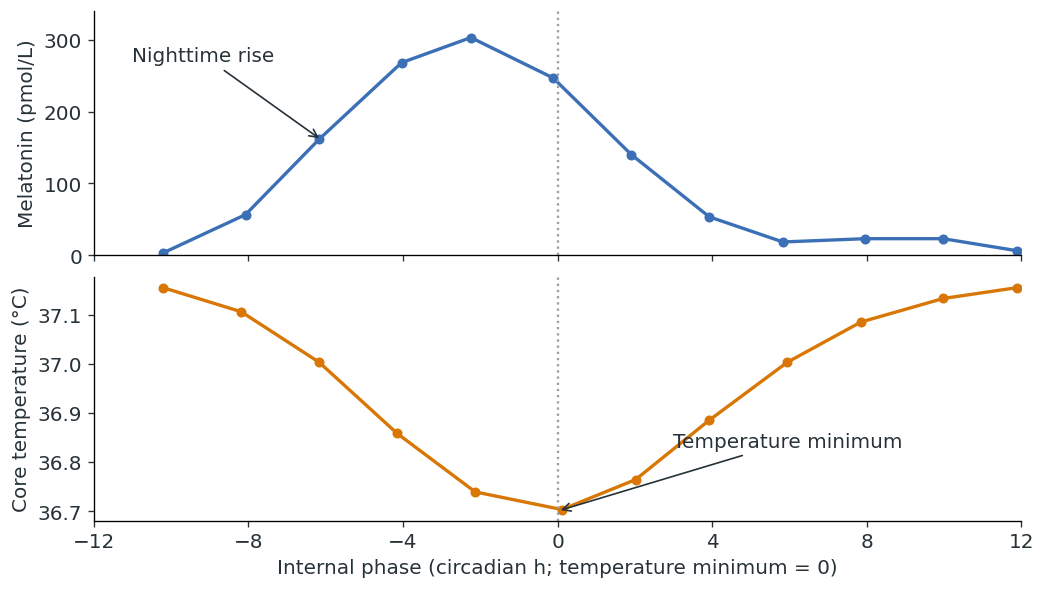

In [29]:
# Published mean profiles, approximately digitized from Wyatt et al. (1999), Fig. 2F/G.
# These profiles illustrate phase markers; SEM is not displayed in this phase-marker illustration.
# The measured sleep/performance comparisons below retain the published SEM.
human_wyatt = pd.read_csv(DATA / "human-wyatt-1999-digitized.csv")
fig, axes = plt.subplots(2, 1, figsize=(8.6, 4.8), sharex=True, layout="constrained")
for ax, series, label, color in zip(axes, ["melatonin", "temperature"],
        ["Melatonin (pmol/L)", "Core temperature (°C)"], [BLUE, ORANGE]):
    d = human_wyatt.query("series == @series").copy()
    d["phase"] = (d.x + 12) % 24 - 12
    d = d.sort_values("phase")
    ax.plot(d.phase, d.value, "o-", color=color, ms=5, lw=2)
    ax.axvline(0, color=GREY, ls=":", lw=1.4)
    ax.set_ylabel(label)
    ax.set_xlim(-12, 12)
    ax.set_xticks(np.arange(-12, 13, 4))
axes[0].set_ylim(0, 340)
axes[0].annotate("Nighttime rise", xy=(-6.1, 160), xytext=(-11, 270),
    arrowprops=dict(arrowstyle="->", color=INK), fontsize=12)
axes[1].annotate("Temperature minimum", xy=(0, 36.70), xytext=(3, 36.83),
    arrowprops=dict(arrowstyle="->", color=INK), fontsize=12)
axes[1].set_xlabel("Internal phase (circadian h; temperature minimum = 0)")
plt.show()


### A 28-hour day

[Czeisler and colleagues](https://doi.org/10.1126/science.284.5423.2177) studied 24 adults for a month in an artificial 28-hour day:

- **18 h 40 min awake** in dim light (≈15 lux)
- **9 h 20 min in bed** in darkness (<0.03 lux)


Black bars are sleep; dashed lines the fitted temperature phase.

<img src="../media/human-czeisler-28h-1999.png" alt="The imposed 28-hour sleep schedule crosses the slowly drifting 24.28-hour temperature rhythm" width="480">


The imposed sleep cycle (28hr) and the physiological oscillator (24.28hr) run at different frequencies.


### The free-running period

Average from 24 participants: the mean intrinsic period was **24.18 h**.

- Temperature, melatonin, and cortisol gave compatible estimates
- Near 24 h, but not exactly the length of Earth's day


## Entrainment

### What keeps us on a 24-hour day?

A clock with intrinsic period $T=24.18$ h falls behind the day by

$$
T-24\ \mathrm{h}=0.18\ \mathrm{h}=10.8\ \mathrm{min}.
$$


### Phase resetting and entrainment

- **Phase resetting:** an input advances or delays subsequent cycles
- **Entrainment:** repeated forcing produces a common period and a stable phase relation to the drive

For proper entrainment, we have phase locking of the circadian oscillator to the earth oscillator--but the influence is one way!


### Light input to the circadian clock

The **suprachiasmatic nucleus (SCN)** in the hypothalamus coordinates daily rhythms.

Retinal ganglion cells containing **melanopsin** send light information to the SCN.

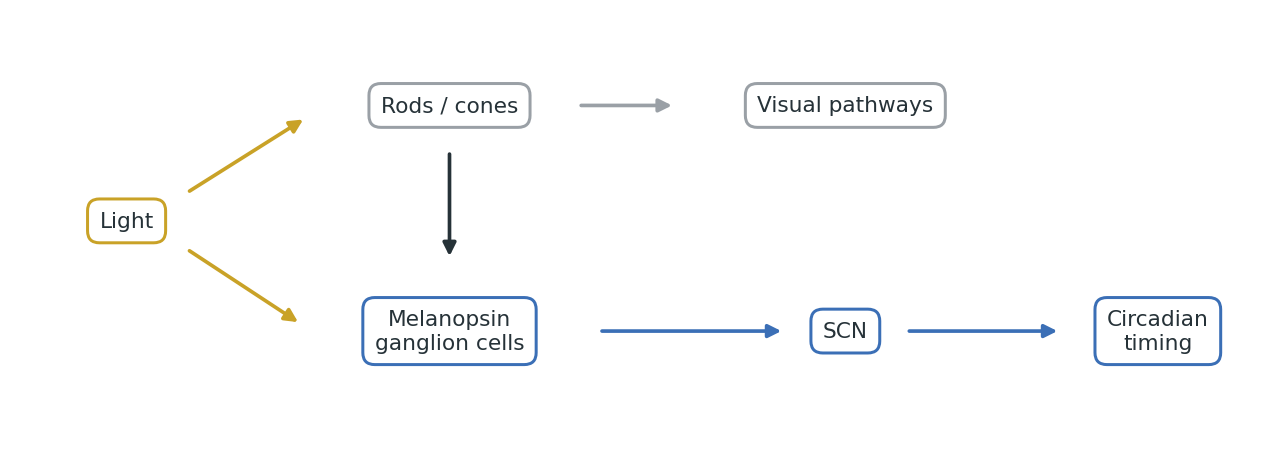

In [30]:
# Circuit schematic: rods/cones also contribute to the melanopsin-cell signal.
fig, ax = plt.subplots(figsize=(10.5, 3.8), layout="constrained")
ax.set(xlim=(0, 12), ylim=(-.25, 4)); ax.axis("off")
nodes = [(1.1, 2, "Light", GOLD), (4.2, 3.1, "Rods / cones", GREY),
         (4.2, .95, "Melanopsin\nganglion cells", BLUE),
         (8.0, 3.1, "Visual pathways", GREY), (8.0, .95, "SCN", BLUE),
         (11.0, .95, "Circadian\ntiming", BLUE)]
for x, y, label, color in nodes:
    ax.text(x, y, label, ha="center", va="center", fontsize=13,
            bbox={"boxstyle":"round,pad=.55", "facecolor":"white",
                  "edgecolor":color, "linewidth":1.8})
for begin, end, color in [((1.65,2.25),(2.85,3.0),GOLD),
                        ((1.65,1.75),(2.8,1.0),GOLD),
                        ((4.2,2.7),(4.2,1.6),INK),
                        ((5.4,3.1),(6.4,3.1),GREY),
                        ((5.6,.95),(7.45,.95),BLUE),
                        ((8.55,.95),(10.1,.95),BLUE)]:
    arrow(ax, begin, end, color=color)
plt.show()


### The retina can entrain even without normal vision

[Zaidi and colleagues](https://doi.org/10.1016/j.cub.2007.11.034) tested light responses in two blind participants without functional rod–cone vision.

6.5 h of blue light suppressed melatonin during exposure and delayed the subsequent rhythm by about **1.2 h**.

### Nightime light phase-response curve

The amount that light (during *night*) can shift phase depends on when it happens:

<img src="../media/human-light-prc-khalsa-2003-reproduction-night.png" alt="Human light phase-response curve with the approximate biological night from circadian phase 18 through 6 shaded gray" width="700">

- Horizontal axis: exposure midpoint; $6\rightarrow18$ = day, $18\rightarrow6$ =  night
- Vertical axis: shift of the melatonin midpoint; positive = advance, negative = delay
- Light in the early biological night delays; light in the late biological night advances

### Jet lag: fixing with light

Consider a trip from Princeton to Europe to give a talk at ETH Zurich, which is **six hours** ahead of us.

If your temperature minimum normally occurs at 04:00 in Princeton, it will initially occur at **10:00 local time** in Zurich.

The phase-response curve gives us a good strategy to adapt:

- **Avoid bright light before 10:00:** light before the temperature minimum produces a delay, *the wrong direction*!
- **Go in bright light after 10:00:** late-morning and early-afternoon light falls after the minimum and advances the clock.

As the temperature minimum moves earlier on successive days, move the bright-light exposure earlier too.



### Jet lag: fixing with melatonin

You can also entrain to a chemical signal

[Sack and colleagues](https://doi.org/10.1056/NEJM200010123431503) studied seven blind participants with free-running rhythms.

Nightly melatonin (10 mg) or placebo 1 h before preferred bedtime

- **Placebo**: clock drift from all participants
- **Melatonin**: Six of seven entrained to 24 h

Each trajectory follows one participant's melatonin-onset time. 

- *Dashed lines*: drift before treatment. 
- *Solid lines*: timing during treatment.

<img src="../media/human-melatonin-entrainment-sack-2000.png" alt="Melatonin treatment stabilizes endogenous melatonin timing in six participants; one continues to drift" width="660">

### Cells in your body can have their own clocks...

The SCN is not the only clock. Cells in many tissues  have their own circadian oscillators.

[Wehrens and colleagues](https://doi.org/10.1016/j.cub.2017.04.059) delayed all three daily meals by **5 h** in ten participants, keeping sleep and light fixed.

| Rhythm measured | Response to later meals |
| --- | --- |
| Melatonin and cortisol | No phase shift |
| Plasma glucose | About 5.7 h later |
| *PER2* (clock gene) expression in fat tissue | About 1 h later |

## Limits of entrainment

### An 18-hour day aboard a submarine

A Trident submarine used a repeating **6 h on duty → 12 h off duty** schedule to rotate shifts.

- No sunlight; off-duty time included sleep and meals
- Clocks onboard still followed 24 h
- [Kelly and colleagues](https://doi.org/10.1177/074873099129000597) sampled salivary melatonin throughout the patrol

In 12 sailors:: **Melatonin period: 24.35 ± 0.18 h** (mean ± SD).

**You can't entrain to an 18 h clock!**


### Can humans entrain to a Martian day?

A Martian solar day lasts **24.65 h**.

For a clock with $T=24.18$ h, the required correction is

$$
24.65-24.18=0.47\ \mathrm{h}=28.2\ \mathrm{min}
$$

of **delay per cycle**.

[Scheer and colleagues](https://doi.org/10.1371/journal.pone.0000721) tested seven people on 24.65-hour and 23.5-hour schedules, for two weeks each.

- **24.65 h:** about 450 lux in the second half of waking, to favor delays
- **23.5 h:** the brighter light in the first half, to favor advances
- Otherwise ≈1.8 lux while awake; darkness during sleep

<img src="../media/human-martian-periods-scheer-2007.png" alt="Measured melatonin periods approach the imposed 23.5-hour and 24.65-hour schedules under appropriately timed light" width="770">

Bars are 95% confidence intervals

**You CAN entrain to the Martian day. There is hope for the *Martian Congressional Republic*!**

## Cyanobacteria

Cyanobacteria are photosynthetic bacteria. Marine blooms can span hundreds of kilometers, and NOAA estimates that *Prochlorococcus* alone accounts for up to 20% of global oxygen production.

The best studied species in the lab is *Synechococcus elongatus*, which harvests light and stores carbon during the day, then draws on those stores at night. 

Cyanobacteria use a **biochemical clock**.

### The KaiABC System

| Protein | Role |
| --- | --- |
| KaiC | Adds and removes phosphate groups on itself |
| KaiA | Promotes KaiC phosphorylation |
| KaiB | Binds KaiC and sequesters KaiA |

This three-protein system will run the clock *in vitro*!


<img src="../media/kaiabc-cell-free-oscillator.png" width="1050" style="display: block; margin: 0 auto;">


At a constant ATP concentration of 4 mM, the percentage of phosphorylated KaiC spontaneously oscillates with a period of 26 hours.

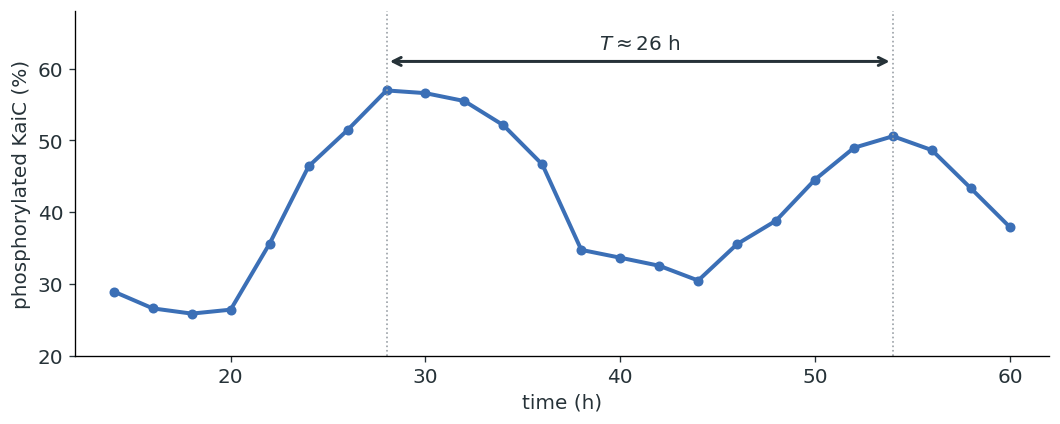

In [31]:
rust_traces = pd.read_csv(DATA / "rust-2011-figure-2-traces-digitized.csv")
KAI_PERIOD_H = 26.0
KAI_PEAK_H = 28.0

fig, ax = plt.subplots(figsize=(9, 3.7))
ax.plot(rust_traces["time_h"], rust_traces["control_percent_p_kaic"],
        "o-", color=BLUE, lw=2.4, ms=5)
for peak in [KAI_PEAK_H, KAI_PEAK_H + KAI_PERIOD_H]:
    ax.axvline(peak, color=GREY, lw=1, ls=":")
ax.annotate("", xy=(28, 61), xytext=(54, 61),
            arrowprops={"arrowstyle": "<->", "color": INK, "lw": 1.8})
ax.text(41, 62.2, r"$T\approx26$ h", ha="center", va="bottom")
ax.set(xlabel="time (h)", ylabel="phosphorylated KaiC (%)",
       xlim=(12, 62), ylim=(20, 68))
fig.tight_layout()
plt.show()


### An ordered phosphorylation cycle

KaiC moves through four chemical states in a preferred order:


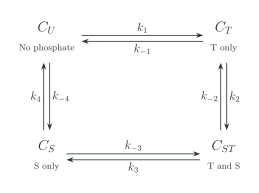

In [32]:
# Four KaiC states; equal-weight arrows show allowed transitions, not net flux.
# Edit the TikZ source here. The rendered SVG is saved in this cell's output.
from pathlib import Path
import shutil
import subprocess
import tempfile

from IPython.display import SVG, display

kaic_tikz = r"""
\documentclass[tikz,dvisvgm,border=12pt]{standalone}
\usepackage{amsmath,tikz-cd}
\usetikzlibrary{arrows.meta}
\definecolor{ink}{HTML}{263238}
\newcommand{\state}[2]{%
  \begin{gathered} C_{#1} \\[-2pt] \text{\normalfont\small #2} \end{gathered}}
\begin{document}
\color{ink}
\begin{tikzcd}[
  row sep=24mm, column sep=42mm,
  cells={nodes={inner sep=7pt, font=\Large}},
  arrows={-{Stealth[length=2.5mm,width=1.8mm]}, line width=0.8pt},
  labels={font=\large}
]
  \state{U}{No phosphate}
    \arrow[r, shift left=3pt, "k_1"]
    \arrow[d, shift left=3pt, "k_{-4}"]
  &
  \state{T}{T only}
    \arrow[l, shift left=3pt, "k_{-1}"]
    \arrow[d, shift left=3pt, "k_2"]
  \\
  \state{S}{S only}
    \arrow[u, shift left=3pt, "k_4"]
    \arrow[r, shift left=3pt, "k_{-3}"]
  &
  \state{ST}{T and S}
    \arrow[u, shift left=3pt, "k_{-2}"]
    \arrow[l, shift left=3pt, "k_3"]
\end{tikzcd}
\end{document}
"""


def kaic_tex_tool(name):
    executable = shutil.which(name) or shutil.which(name, path="/Library/TeX/texbin")
    if executable is None:
        raise RuntimeError(
            "Regenerating this diagram needs LaTeX (TikZ, tikz-cd, standalone) "
            "and dvisvgm. See the repository README for setup."
        )
    return executable


with tempfile.TemporaryDirectory(prefix="kaic-tikz-") as directory:
    work = Path(directory)
    (work / "kai-cycle.tex").write_text(kaic_tikz, encoding="utf-8")
    commands = [
        [kaic_tex_tool("latex"), "-interaction=nonstopmode", "-halt-on-error", "kai-cycle.tex"],
        [kaic_tex_tool("dvisvgm"), "--no-fonts", "--bbox=papersize", "--zoom=1.6",
         "--output=kai-cycle.svg", "kai-cycle.dvi"],
    ]
    for command in commands:
        result = subprocess.run(command, cwd=work, capture_output=True, text=True, timeout=60)
        if result.returncode:
            raise RuntimeError(
                f"{Path(command[0]).name} failed:\n{result.stdout[-4000:]}\n{result.stderr[-2000:]}"
            )
    kaic_svg = (work / "kai-cycle.svg").read_text(encoding="utf-8")

display(SVG(data=kaic_svg))


KaiA pushes KaiC around the phosphorylation cycle toward $C_S$.

- $C_S$ recruits KaiB, which sequesters KaiA.
- Without free KaiA, KaiC dephosphorylates and $C_S$ disappears.
- KaiA is released, and phosphorylation starts again.

KaiA represses it's own effective activity KaiA off—but only after a delay → *delayed negative feedback*


<img src="../media/kaiabc-delayed-feedback.svg" width="1050" style="display: block; margin: 0 auto;">


### Delayed negative feedback



[Stricker et al. (2008)](https://doi.org/10.1038/nature07389) put *lacI* and a GFP reporter under copies of the same LacI-repressible promoter in *E. coli*.

<img src="../media/stricker-negative-feedback-circuit.svg" alt="LacI represses its own promoter and the reporter promoter; expression and assembly introduce a delay." width="1050" style="display: block; margin: 0 auto;">


$$
\frac{dy}{dt}=\frac{v_{\max}}{1+\left[y(t-\tau)/C_0\right]^n}-\gamma y(t).
$$

For small perturbations from the steady state $y^*$, $y(t)=y^*+u(t)$:

$$
\frac{du}{dt}=-\gamma u(t)-\beta u(t-\tau).
$$

$\gamma$ is the degradation rate, while $\beta>0$ is the magnitude of the slope of the repression curve at $y^*$:

$$
\beta=-\left.\frac{d}{dy}\left[\frac{v_{\max}}{1+(y/C_0)^n}\right]\right|_{y=y^*}
=\gamma n\frac{(y^*/C_0)^n}{1+(y^*/C_0)^n}
$$

For the trial solution $u(t)=e^{i\omega t}$:

$$
i\omega+\gamma+\beta e^{-i\omega\tau}=0,
$$

Separating real and imaginary parts gives

$$
\gamma+\beta\cos(\omega\tau)=0,\qquad
\omega-\beta\sin(\omega\tau)=0.
$$

If feedback is stronger than degradation, $\beta>\gamma$, the steady state loses stability at

$$
\tau=\tau_c=\frac{\cos^{-1}(-\gamma/\beta)}{\sqrt{\beta^2-\gamma^2}}
$$

and oscillates at

$$
\omega_c=\sqrt{\beta^2-\gamma^2}.
$$

<img src="../media/stricker-2008-negative-feedback-traces.png" alt="Measured single-cell GFP fluorescence trajectories from the negative-feedback-only E. coli oscillator." width="760" style="display: block; margin: 0 auto;">

### A minimal kinetic model of KaiABC

All KaiC molecules draw from the same finite pool of KaiA:

$$
[\mathrm{KaiA}]_{\mathrm{free}}=\max\left([\mathrm{KaiA}]_{\mathrm{total}}-2[C_S],0\right).
$$

Because every KaiC molecule draws from this pool, sequestration couples the whole population.

The reaction rates saturate with free KaiA:

$$
f([\mathrm{KaiA}]_{\mathrm{free}})=\frac{[\mathrm{KaiA}]_{\mathrm{free}}}{K_A+[\mathrm{KaiA}]_{\mathrm{free}}}.
$$

The simulation below uses a simplified 4-state model with measured KaiA-dependent transition rates.

**Delay + negative feedback + saturation produce a limit cycle.**

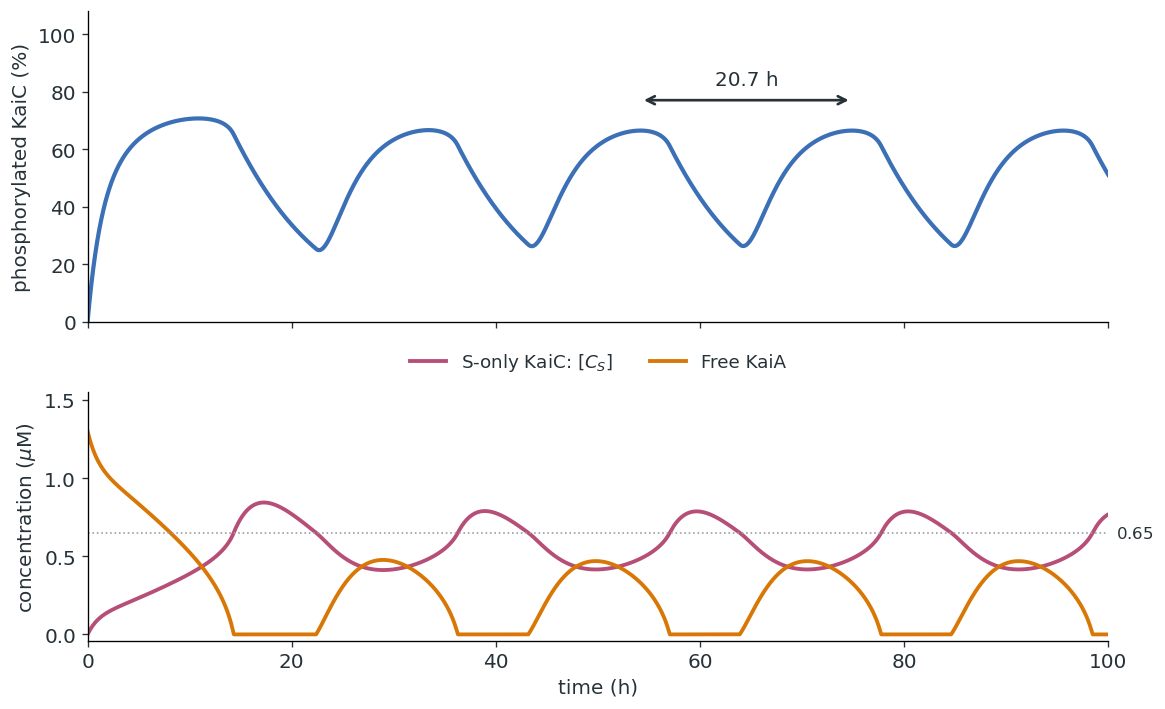

In [33]:
# Rust four-state model: concentrations in micromolar; time in hours.
# Rate measurements and parameter provenance: media/README.md.
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

KAIC_TOTAL = 3.4
KAIA_TOTAL = 1.3


def kaic_rates(a_free):
    # Saturating KaiA dependence, measured in partial-reaction experiments.
    response = a_free / (0.43 + a_free)
    k1 = 0.479077 * response             # U -> T
    k2 = 0.212923 * response             # T -> ST
    k3 = 0.31 - 0.319385 * response      # ST -> S
    k4 = 0.11 - 0.133077 * response      # S -> U
    k_minus1 = 0.21 + 0.0798462 * response  # T -> U
    k_minus2 = 0.173 * response          # ST -> T
    k_minus3 = 0.505692 * response       # S -> ST
    k_minus4 = 0.0532308 * response      # U -> S
    return k1, k2, k3, k4, k_minus1, k_minus2, k_minus3, k_minus4


def kaic_rhs(time, concentrations):
    c_t, c_st, c_s = concentrations
    c_u = KAIC_TOTAL - c_t - c_st - c_s
    a_free = max(0., KAIA_TOTAL - 2 * c_s)
    k1, k2, k3, k4, km1, km2, km3, km4 = kaic_rates(a_free)
    # Each line is incoming reactions minus outgoing reactions.
    dc_t = k1*c_u + km2*c_st - (km1 + k2)*c_t
    dc_st = k2*c_t + km3*c_s - (km2 + k3)*c_st
    dc_s = k3*c_st + km4*c_u - (km3 + k4)*c_s
    return [dc_t, dc_st, dc_s]


kaic_time = np.linspace(0, 300, 30001)
kaic_solution = solve_ivp(
    kaic_rhs, (0, 300), [0., 0., 0.], t_eval=kaic_time,
    rtol=1e-9, atol=1e-11, max_step=.1,
)
assert kaic_solution.success
kaic_phosphorylated = kaic_solution.y.sum(axis=0) / KAIC_TOTAL
kaic_peak_indices = find_peaks(kaic_phosphorylated, prominence=.1)[0]
kaic_late_peaks = kaic_peak_indices[kaic_time[kaic_peak_indices] > 150]
kaic_period = np.diff(kaic_time[kaic_late_peaks]).mean()
assert 20 < kaic_period < 22
assert np.min(kaic_solution.y) >= -1e-8
assert np.max(kaic_solution.y.sum(axis=0)) <= KAIC_TOTAL + 1e-8

# Aligned panels connect the measured observable to the feedback mechanism.
fig, (ax_p, ax_a) = plt.subplots(
    2, 1, figsize=(9.6, 5.8), sharex=True,
    gridspec_kw={"height_ratios": [1.25, 1]}, constrained_layout=True,
)
ax_p.plot(kaic_time, 100 * kaic_phosphorylated, color=BLUE, lw=2.5)
ax_p.set(ylabel="phosphorylated KaiC (%)", ylim=(0, 108))
visible_peaks = kaic_peak_indices[(kaic_time[kaic_peak_indices] > 35)
                                  & (kaic_time[kaic_peak_indices] < 85)]
t_left, t_right = kaic_time[visible_peaks[:2]]
ax_p.annotate("", xy=(t_left, 77), xytext=(t_right, 77),
              arrowprops={"arrowstyle": "<->", "color": INK, "lw": 1.6})
ax_p.text((t_left + t_right) / 2, 81, f"{kaic_period:.1f} h",
          ha="center", va="bottom", color=INK)
ax_a.plot(kaic_time, kaic_solution.y[2], color=PINK, lw=2.3,
          label=r"S-only KaiC: $[C_S]$")
ax_a.plot(kaic_time, np.maximum(0, KAIA_TOTAL - 2 * kaic_solution.y[2]),
          color=ORANGE, lw=2.3, label="Free KaiA")
ax_a.axhline(KAIA_TOTAL / 2, color=GREY, ls=":", lw=1)
ax_a.text(100.8, KAIA_TOTAL / 2, r"$0.65$", va="center", fontsize=10)
ax_a.set(xlabel="time (h)", ylabel=r"concentration ($\mu$M)",
          xlim=(0, 100), ylim=(-.04, 1.55))
ax_a.legend(loc="upper center", bbox_to_anchor=(.5, 1.23), ncol=2, frameon=False)
plt.show()


### Entrainment of KaiABC to sunlight

KaiABC does not sense light directly.

Darkness raises ADP relative to ATP in the cell, slowing KaiC phosphorylation.

***In vitro*, day and night can be imposed by switching between ATP-rich and ADP-rich buffers.**


### Testing different photoperiods

Leypunskiy et al. imposed a 24-hour cycle through buffer exchange:

- **Day:** ATP-only buffer
- **Night:** add ADP, reducing the ATP fraction to 25%

Entrainment by the third day.


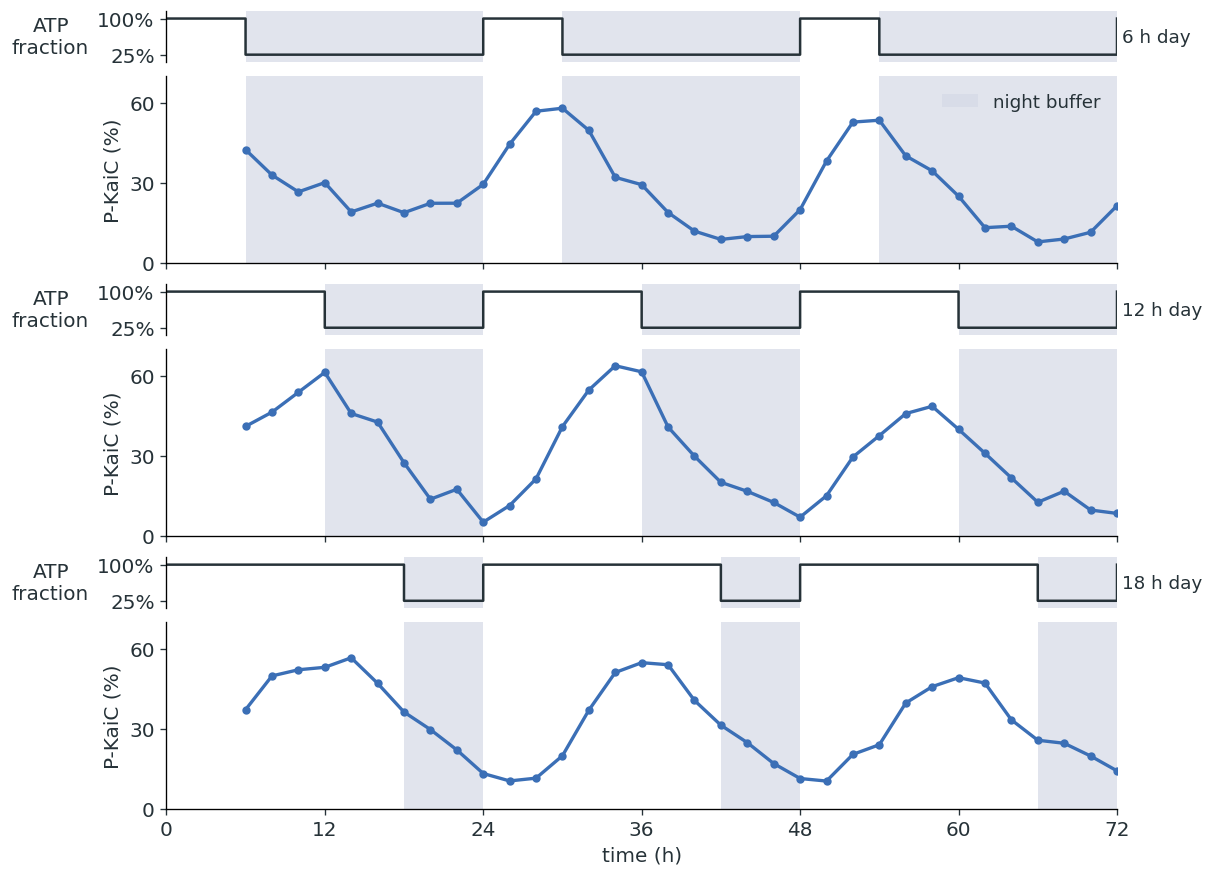

In [34]:
kai_entrainment = pd.read_csv(DATA / "source" / "elife-23539-fig2-data1-v2.csv")

fig = plt.figure(figsize=(10, 7.2), layout="constrained")
gs = fig.add_gridspec(6, 1, height_ratios=[0.38, 1.4] * 3, hspace=0.05)
for row, day_length in enumerate([6, 12, 18]):
    input_ax = fig.add_subplot(gs[2*row])
    output_ax = fig.add_subplot(gs[2*row+1], sharex=input_ax)
    t = np.linspace(0, 72, 1441)
    atp_fraction = np.where(t % 24 < day_length, 1.0, 0.25)
    input_ax.step(t, atp_fraction, where="post", color=INK, lw=1.5)
    input_ax.set(ylim=(0.1, 1.15), yticks=[0.25, 1], yticklabels=["25%", "100%"])
    input_ax.set_ylabel("ATP\nfraction", rotation=0, labelpad=28, va="center")
    input_ax.text(1.005, 0.5, f"{day_length} h day", transform=input_ax.transAxes,
                  va="center", fontsize=11)
    input_ax.spines["bottom"].set_visible(False)
    input_ax.tick_params(axis="x", bottom=False, labelbottom=False)
    subset = kai_entrainment[kai_entrainment["day_length"] == day_length]
    for a in [input_ax, output_ax]:
        shade_nights(a, day_length)
        a.set_xlim(0, 72)
    output_ax.plot(subset["time_hrs"], subset["percent_KaiC_phosphorylation"],
                   "o-", color=BLUE, lw=2, ms=4)
    output_ax.set(ylabel="P-KaiC (%)", ylim=(0, 70), yticks=[0, 30, 60])
    output_ax.set_xticks(np.arange(0, 73, 12))
    if row < 2:
        output_ax.tick_params(labelbottom=False)
    else:
        output_ax.set_xlabel("time (h)")
    if row == 0:
        output_ax.legend(handles=[Patch(facecolor=NIGHT, label="night buffer")],
                         loc="upper right", frameon=False)
plt.show()


## Let's build a Kuramoto-like model of coupling to day-night cycle

KaiABC clock:

$$
\dot\theta=\omega,\qquad T=\frac{2\pi}{\omega}.
$$

Environmental (sun) clock:

$$
\Theta_d(t)=\Omega_d t,\qquad T_d=\frac{2\pi}{\Omega_d}.
$$

### Kuramoto-like coupling

$$
\dot\theta=\omega+F\sin(\Theta_d-\theta),
\qquad F>0.
$$


### Relative-phase dynamics

Define

$$
\phi=\theta-\Theta_d,\qquad
\Delta\omega=\omega-\Omega_d.
$$

As in Lecture 3:

$$
\begin{aligned}
\dot\phi
&=\dot\theta-\dot\Theta_d\\
&=\omega-\Omega_d-F\sin\phi\\
&=\boxed{\Delta\omega-F\sin\phi}.
\end{aligned}
$$


### Mode-locking

Set $\dot\phi=0$:

$$
\sin\phi^*=\frac{\Delta\omega}{F}.
$$

Stable locking requires

$$
|\Delta\omega|<F,\qquad
\phi^*=\sin^{-1}\!\left(\frac{\Delta\omega}{F}\right).
$$

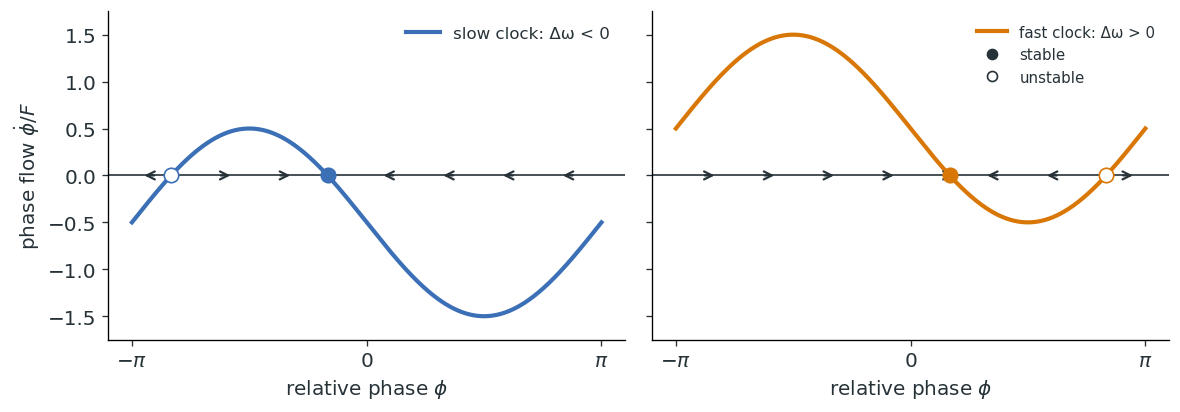

In [35]:
phi_grid = np.linspace(-np.pi, np.pi, 601)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharex=True, sharey=True)
for ax, ratio, label, color in zip(axes, [-0.5, 0.5],
        ["slow clock: Δω < 0", "fast clock: Δω > 0"], [BLUE, ORANGE]):
    flow = ratio - np.sin(phi_grid)
    ax.plot(phi_grid, flow, color=color, lw=2.5, label=label)
    ax.axhline(0, color=INK, lw=1)
    stable = np.arcsin(ratio)
    unstable = float(wrap_phase(np.pi - stable))
    ax.scatter(stable, 0, s=75, color=color, zorder=5)
    ax.scatter(unstable, 0, s=75, facecolors="white", edgecolors=color, zorder=5)
    for phase in np.linspace(-2.8, 2.8, 8):
        direction = np.sign(ratio - np.sin(phase))
        ax.annotate("", (phase + 0.22*direction, 0), (phase, 0),
                    arrowprops={"arrowstyle": "->", "color": INK, "lw": 1.3})
    ax.set(xlabel=r"relative phase $\phi$", xticks=[-np.pi, 0, np.pi],
           xticklabels=[r"$-\pi$", "0", r"$\pi$"], ylim=(-1.75, 1.75))
    ax.legend(frameon=False, loc="upper right", fontsize=10)
axes[0].set_ylabel(r"phase flow $\dot\phi/F$")
axes[1].plot([], [], "o", color=INK, label="stable")
axes[1].plot([], [], "o", color=INK, markerfacecolor="white", label="unstable")
axes[1].legend(frameon=False, loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()


### The primary $1{:}1$ Arnold tongue

The wedge-shaped $1{:}1$ locking region in the $F-\Omega_d$ plane is called an *Arnold tongue*. Its boundaries satisfy

$$
F=|\omega-\Omega_d|
$$


Inside the tongue, stronger forcing can compensate for a larger frequency mismatch.


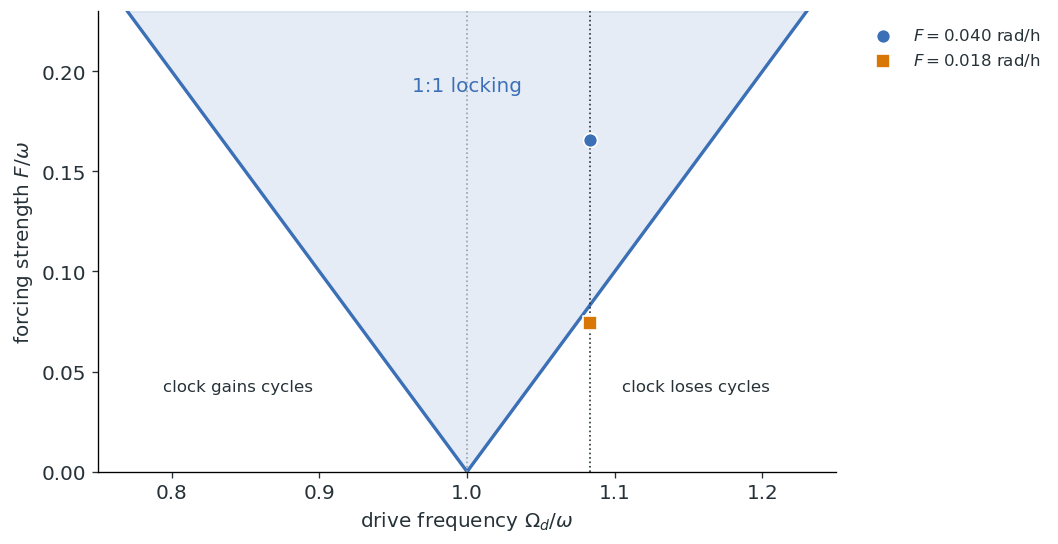

In [36]:
# Illustrative 26-hour clock driven by a 24-hour day.
clock_omega = TAU / KAI_PERIOD_H
drive_omega = TAU / 24.0
clock_detuning = clock_omega - drive_omega
locked_forcing = 0.040
slipping_forcing = 0.018

forcing_axis = np.linspace(0, 0.23, 400)
fig, ax = plt.subplots(figsize=(9, 4.7))
ax.fill_betweenx(forcing_axis, 1-forcing_axis, 1+forcing_axis, color=BLUE, alpha=0.13)
ax.plot(1-forcing_axis, forcing_axis, color=BLUE, lw=2)
ax.plot(1+forcing_axis, forcing_axis, color=BLUE, lw=2)
ax.axvline(1, color=GREY, lw=1, ls=":")
ax.text(1, 0.19, "1:1 locking", ha="center", color=BLUE)
ax.text(0.845, 0.04, "clock gains cycles", ha="center", fontsize=10)
ax.text(1.155, 0.04, "clock loses cycles", ha="center", fontsize=10)
ratio = drive_omega / clock_omega
ax.plot([ratio, ratio], [0, 0.23], ":", color=INK, lw=1)
ax.scatter([ratio], [locked_forcing/clock_omega], s=70, color=BLUE,
           edgecolor="white", zorder=4, label=r"$F=0.040$ rad/h")
ax.scatter([ratio], [slipping_forcing/clock_omega], s=70, color=ORANGE, marker="s",
           edgecolor="white", zorder=4, label=r"$F=0.018$ rad/h")
ax.set(xlabel=r"drive frequency $\Omega_d/\omega$", ylabel=r"forcing strength $F/\omega$",
       xlim=(0.75, 1.25), ylim=(0, 0.23))
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)
fig.tight_layout()
plt.show()


## Jet lag in the phase model

Start with the 26-hour KaiABC oscillator. For a $\pi/2$ shift:

$$
\Theta_d\longrightarrow\Theta_d+\frac{\pi}{2},
\qquad
\phi\longrightarrow\phi-\frac{\pi}{2}.
$$

The clock starts six hours behind its entrained timing. Assuming you are in the mode-locking regime, this now takes time to synchronize with the environment:


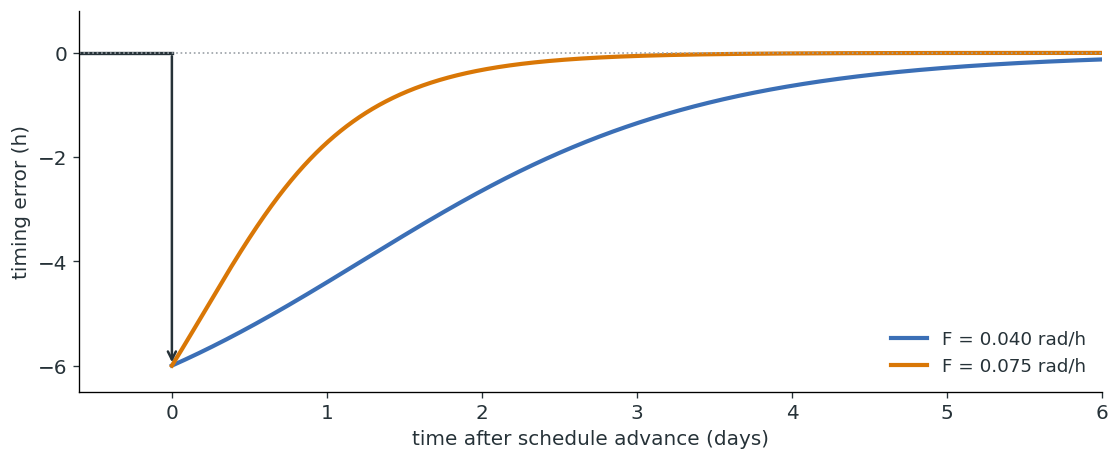

In [37]:
fig, ax = plt.subplots(figsize=(9.5, 4))
recovery_runs = []
for forcing, color, label in [(0.04, BLUE, "F = 0.040 rad/h"),
                               (0.075, ORANGE, "F = 0.075 rad/h")]:
    equilibrium = np.arcsin(clock_detuning/forcing)
    time, phi = simulate_relative_phase(clock_detuning, forcing, equilibrium-np.pi/2,
                                         t_end=144, dt=0.05)
    # Convert relative angle to hours of the imposed 24-hour schedule.
    error_h = (phi-equilibrium)/drive_omega
    recovery_runs.append((time, error_h))
    ax.plot(time/24, error_h, color=color, lw=2.5, label=label)
ax.plot([-1, 0], [0, 0], color=INK, lw=2)
ax.annotate("", (0, -6), (0, 0),
            arrowprops={"arrowstyle": "->", "color": INK, "lw": 1.5})
ax.axhline(0, color=GREY, ls=":", lw=1)
ax.set(xlabel="time after schedule advance (days)", ylabel="timing error (h)",
       xlim=(-0.6, 6), ylim=(-6.5, 0.8), yticks=[-6, -4, -2, 0])
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()


### How long does it take to relax?

In Lecture 3 we looked at the stability of the mode-locked state using a small perturbation, $\phi=\phi^*+\eta$:

$$
\dot\eta=-F\cos\phi^*\,\eta
=-\sqrt{F^2-\Delta\omega^2}\,\eta.
$$

The relaxation time is then:

$$
t_{\mathrm{relax}}=\frac{1}{\sqrt{F^2-\Delta\omega^2}}.
$$

Recovery becomes slow near the Arnold-tongue boundary.

For a larger phase shift, we use the full nonlinear phase flow:

$$
t(\phi_0\to\phi)=\int_{\phi_0}^{\phi}
\frac{d\phi'}{\Delta\omega-F\sin\phi'}.
$$

Near the unstable phase, return takes a long time; beyond it, the clock slips by one cycle before relocking.

[Mouse experiments](https://doi.org/10.1038/srep46702) find slower recovery after an eight-hour advance than after an eight-hour delay, and faster re-entrainment when the advance is split into two four-hour steps.


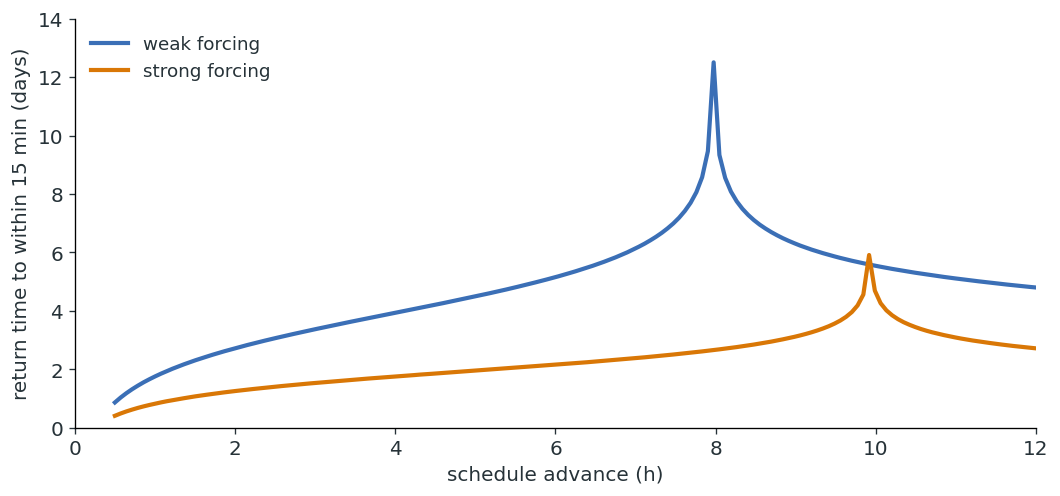

In [38]:
advance_hours = np.linspace(0.5, 12, 161)
return_window_h = 0.25
return_window_phase = drive_omega * return_window_h

fig, ax = plt.subplots(figsize=(9, 4.3))
for forcing, color, label in [(0.04, BLUE, "weak forcing"),
                               (0.075, ORANGE, "strong forcing")]:
    equilibrium = np.arcsin(clock_detuning / forcing)
    return_days = []
    for advance in advance_hours:
        time, phi = simulate_relative_phase(
            clock_detuning, forcing, equilibrium - drive_omega * advance,
            t_end=30 * 24, dt=0.05,
        )
        returned = np.flatnonzero(
            np.abs(wrap_phase(phi - equilibrium)) < return_window_phase
        )
        return_days.append(time[returned[0]] / 24 if len(returned) else np.nan)
    ax.plot(advance_hours, return_days, color=color, lw=2.5, label=label)

ax.set(xlabel="schedule advance (h)",
       ylabel="return time to within 15 min (days)",
       xlim=(0, 12), ylim=(0, 14))
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


## Circadian rhythms in fruit flies

Animals such as *Drosophila melanogaster* also have circadian rhythms. E.g. flies are most active around dawn and dusk.

But, in constant darkness, activity and rest continue to cycle with a period close to 24 hours.

<img src="../media/drosophila-melanogaster-closeup.jpg" alt="Close-up photograph of a fruit fly, Drosophila melanogaster" width="900" style="display: block; margin: 0 auto;">


### Fruit flies use a genetic circadian clock

Konopka and Benzer found mutations in one fruit-fly gene, *period*, that changed the free-running period of locomotor activity.

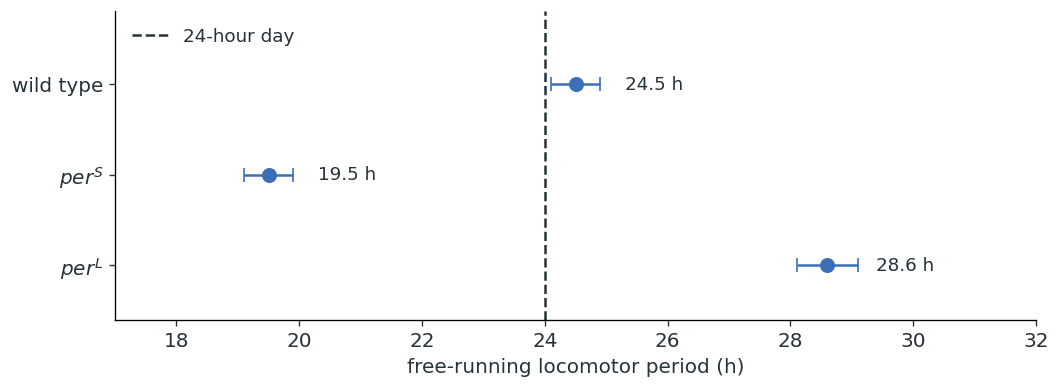

In [39]:
period_mutants = pd.read_csv(DATA / "konopka-benzer-1971-period-mutants.csv")
rhythmic = period_mutants.dropna(subset=["period_h"]).copy()
fig, ax = plt.subplots(figsize=(9, 3.4))
y = np.array([2, 1, 0])
ax.axvline(24, color=INK, lw=1.5, ls="--", label="24-hour day")
ax.errorbar(rhythmic["period_h"], y, xerr=rhythmic["reported_uncertainty_h"],
            fmt="o", color=BLUE, ms=8, capsize=4)
for period, yy in zip(rhythmic["period_h"], y):
    ax.text(period+0.8, yy, f"{period:.1f} h", va="center", fontsize=11)
ax.set(xlabel="free-running locomotor period (h)", yticks=[2, 1, 0],
       yticklabels=["wild type", r"$per^S$", r"$per^L$"], xlim=(17, 32), ylim=(-0.6, 2.8))
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


### The fly clock is a delayed negative-feedback circuit

CLK/CYC activate transcription of *period* and *timeless*.

PER/TIM accumulate, enter the nucleus, and repress CLK/CYC.

Light activates CRYPTOCHROME (CRY), which removes TIM and resets the loop.


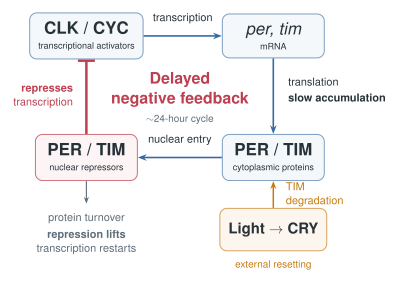

In [40]:
# Edit the TikZ source here. The rendered SVG is saved in this cell's output.
from pathlib import Path
import shutil
import subprocess
import tempfile

from IPython.display import SVG, display

fly_tikz = r"""
\documentclass[tikz,dvisvgm,border=10pt]{standalone}
\usepackage[T1]{fontenc}
\usepackage{helvet}
\renewcommand{\familydefault}{\sfdefault}
\usetikzlibrary{arrows.meta,calc}
\definecolor{ink}{HTML}{263238}
\definecolor{muted}{HTML}{5E6C78}
\definecolor{flowblue}{HTML}{3569A0}
\definecolor{repression}{HTML}{BE3F50}
\definecolor{light}{HTML}{C77A10}
\begin{document}
\begin{tikzpicture}[
  font=\sffamily, text=ink,
  molecule/.style={rounded corners=2.5mm, line width=1pt,
    minimum width=36mm, minimum height=15mm, align=center,
    inner sep=3mm, draw=flowblue!65, fill=flowblue!5},
  flow/.style={-{Stealth[length=3.1mm,width=2.3mm]},
    draw=flowblue, line width=1.6pt},
  inhibit/.style={-{Bar[width=6mm]}, draw=repression, line width=2.5pt},
  input/.style={-{Stealth[length=2.8mm,width=2.1mm]},
    draw=light, line width=1.5pt},
  process/.style={font=\fontsize{11}{14}\selectfont, align=center},
  note/.style={font=\fontsize{10}{13}\selectfont, text=muted, align=center}
]
  % Four sides of one loop; the inhibitory return is its strongest edge.
  \node[molecule] (clk) at (0,0)
    {{\fontsize{17}{20}\selectfont\bfseries CLK / CYC}\\[3pt]
     {\small transcriptional activators}};
  \node[molecule] (mrna) at (6.6,0)
    {{\fontsize{17}{20}\selectfont\itshape per, tim}\\[3pt]
     {\small mRNA}};
  \node[molecule] (proteins) at (6.6,-4.3)
    {{\fontsize{17}{20}\selectfont\bfseries PER / TIM}\\[3pt]
     {\small cytoplasmic proteins}};
  \node[molecule, draw=repression!75, fill=repression!6] (nuclear) at (0,-4.3)
    {{\fontsize{17}{20}\selectfont\bfseries PER / TIM}\\[3pt]
     {\small nuclear repressors}};

  \draw[flow] (clk.east) -- node[process, above=3mm] {transcription} (mrna.west);
  \draw[flow] (mrna.south) -- (proteins.north);
  \node[process, anchor=west, align=left] at (7,-1.9)
    {translation\\[2pt]\textbf{slow accumulation}};
  \draw[flow] (proteins.west) --
    node[process, above=3mm] {nuclear entry} (nuclear.east);
  \draw[inhibit] (nuclear.north) -- (clk.south);
  \node[process, text=repression, anchor=east, align=right] at (-0.35,-2.15)
    {\textbf{represses}\\transcription};

  \node[align=center, text=repression, font=\fontsize{16}{20}\selectfont]
    at (3.3,-1.9) {\textbf{Delayed}\\\textbf{negative feedback}};
  \node[note] at (3.3,-2.95) {$\sim$24-hour cycle};

  % Clearance releases the brake, so the next cycle can begin.
  \draw[-{Stealth[length=2.4mm]}, draw=muted, line width=1.1pt]
    (nuclear.south) -- ++(0,-0.8)
    node[below=2mm, process, text=muted]
      {protein turnover\\[3pt]\textbf{repression lifts}\\transcription restarts};

  % Light is a separate perturbation of TIM, not a forward step in the loop.
  \node[molecule, minimum width=28mm, draw=light!70, fill=light!7]
    (cry) at (6.6,-6.85)
    {{\fontsize{15}{18}\selectfont\bfseries Light $\to$ CRY}};
  \node[note, text=light, below=2mm] at (cry.south) {external resetting};
  \draw[input] (cry.north) --
    node[process, text=light, right=3mm, align=left]
      {TIM\\degradation} (proteins.south);
\end{tikzpicture}
\end{document}
"""

def fly_tex_tool(name):
    executable = shutil.which(name) or shutil.which(name, path="/Library/TeX/texbin")
    if executable is None:
        raise RuntimeError("Regenerating this diagram needs LaTeX and dvisvgm. See README.md.")
    return executable


with tempfile.TemporaryDirectory(prefix="fly-clock-tikz-") as directory:
    work = Path(directory)
    (work / "fly-clock.tex").write_text(fly_tikz, encoding="utf-8")
    commands = [
        [fly_tex_tool("latex"), "-interaction=nonstopmode", "-halt-on-error", "fly-clock.tex"],
        [fly_tex_tool("dvisvgm"), "--no-fonts", "--bbox=papersize", "--zoom=1.45",
         "--output=fly-clock.svg", "fly-clock.dvi"],
    ]
    for command in commands:
        result = subprocess.run(command, cwd=work, capture_output=True, text=True, timeout=60)
        if result.returncode:
            raise RuntimeError(
                f"{Path(command[0]).name} failed:\n{result.stdout[-4000:]}\n{result.stderr[-2000:]}"
            )
    fly_svg = (work / "fly-clock.svg").read_text(encoding="utf-8")

display(SVG(data=fly_svg))


### Entrainment with light

A one-hour light pulse at different circadian times shifts subsequent activity in darkness.

The same pulse delays the clock early at night and advances it late at night.

<img src="../media/drosophila-light-pulse-prc.png" width="760" style="display: block; margin: 0 auto;">

## Sources

### Humans

- Joshua Foer and Michel Siffre, [“Caveman: An Interview with Michel Siffre”](https://www.cabinetmagazine.org/issues/30/foer_siffre.php) (2008).
- Charles A. Czeisler *et al.*, [“Stability, Precision, and Near-24-Hour Period of the Human Circadian Pacemaker”](https://doi.org/10.1126/science.284.5423.2177) (1999).
- James K. Wyatt *et al.*, [“Circadian temperature and melatonin rhythms, sleep, and neurobehavioral function in humans living on a 20-h day”](https://doi.org/10.1152/ajpregu.1999.277.4.R1152) (1999).
- Farhan H. Zaidi *et al.*, [“Short-Wavelength Light Sensitivity of Circadian, Pupillary, and Visual Awareness in Humans Lacking an Outer Retina”](https://doi.org/10.1016/j.cub.2007.11.034) (2007).
- Sat Bir S. Khalsa *et al.*, [“A phase response curve to single bright light pulses in human subjects”](https://doi.org/10.1113/jphysiol.2003.040477) (2003).
- Frank A. J. L. Scheer *et al.*, [“Plasticity of the Intrinsic Period of the Human Circadian Timing System”](https://doi.org/10.1371/journal.pone.0000721) (2007).
- Tamsin L. Kelly *et al.*, [“Nonentrained Circadian Rhythms of Melatonin in Submariners Scheduled to an 18-Hour Day”](https://doi.org/10.1177/074873099129000597) (1999).
- Mathias Basner *et al.*, [“Mars 520-d mission simulation reveals protracted crew hypokinesis and alterations of sleep duration and timing”](https://doi.org/10.1073/pnas.1212646110) (2013).

### Cyanobacteria and flies

- Masayuki Nakajima *et al.*, [“Reconstitution of circadian oscillation of cyanobacterial KaiC phosphorylation in vitro”](https://doi.org/10.1126/science.1108451) (2005).
- Michael J. Rust *et al.*, [“Ordered phosphorylation governs oscillation of a three-protein circadian clock”](https://doi.org/10.1126/science.1148596) (2007).
- Michael J. Rust, Susan S. Golden, and Erin K. O'Shea, [“Light-driven changes in energy metabolism directly entrain the cyanobacterial circadian oscillator”](https://doi.org/10.1126/science.1197243) (2011).
- Connie Phong *et al.*, [“Robust and tunable circadian rhythms from differentially sensitive catalytic domains”](https://doi.org/10.1073/pnas.1212113110) (2013).
- Eugene Leypunskiy *et al.*, [“The cyanobacterial circadian clock follows midday in vivo and in vitro”](https://doi.org/10.7554/eLife.23539) (2017).
- Ronald J. Konopka and Seymour Benzer, [“Clock mutants of Drosophila melanogaster”](https://doi.org/10.1073/pnas.68.9.2112) (1971).
- Christa Kistenpfennig *et al.*, [“Phase-Shifting the Fruit Fly Clock without Cryptochrome”](https://doi.org/10.1177/0748730411434390) (2012).
- Mark P. Myers *et al.*, [“Light-induced degradation of TIMELESS and entrainment of the Drosophila circadian clock”](https://doi.org/10.1126/science.271.5256.1736) (1996).
- Pooja Vinayak *et al.*, [“Exquisite light sensitivity of Drosophila melanogaster cryptochrome”](https://doi.org/10.1371/journal.pgen.1003615) (2013).
- Yan Ouyang *et al.*, [“Resonating circadian clocks enhance fitness in cyanobacteria”](https://doi.org/10.1073/pnas.95.15.8660) (1998).
- Brigitte Grima *et al.*, [“Morning and evening peaks of activity rely on different clock neurons of the Drosophila brain”](https://doi.org/10.1038/nature02935) (2004).
- NASA Earth Observatory, [“Greening the Gulf of Finland”](https://science.nasa.gov/earth/earth-observatory/greening-the-gulf-of-finland-150197/) (2022).
- NOAA National Ocean Service, [“How much oxygen comes from the ocean?”](https://oceanservice.noaa.gov/facts/ocean-oxygen.html) (n.d.).
